In [22]:
import os
os.makedirs("charts", exist_ok=True)

TASK 1 - Data Loading & Exploratory Analysis

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

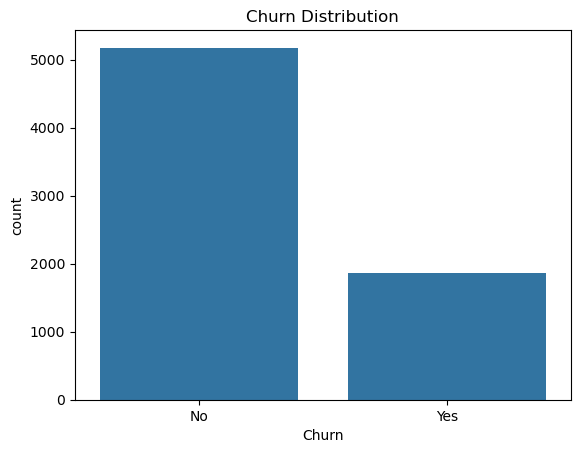

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2281.916928
std         0.368612    24.559481       30.090047   2265.270398
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    402.225000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3786.600000
max         1

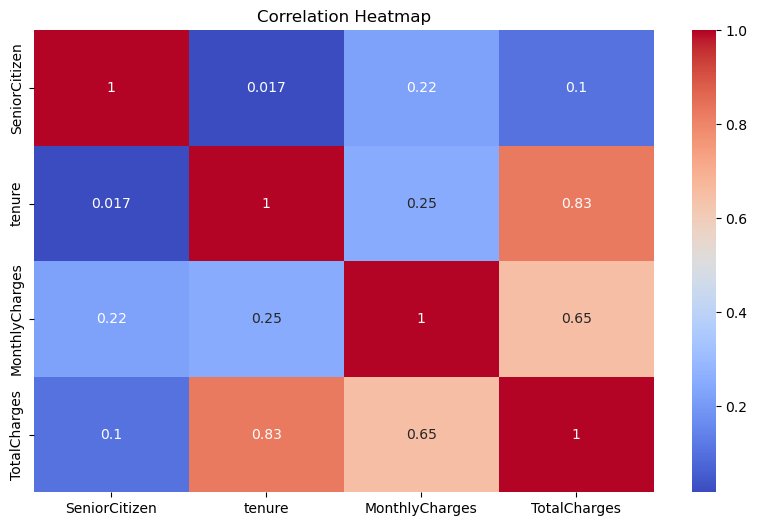

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Shape
print(df.shape)

# To access First 10 rows
df.head(10)

# To know Data types
df.info()

# Perform Target distribution
print(df['Churn'].value_counts())

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# To Find Missing values
print(df.isnull().sum())

# Convert TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# To Fill missing values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# To get Summary statistics
print(df.describe())

# Correlation heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("charts/heatmap.png")
plt.show()

TASK 2 - Data Preprocessing & Feature Engineering

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
    

df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

df['SeniorWithNoSupport'] = (
    (df['SeniorCitizen'] == 1) &
    (df['TechSupport'] == 'No')
).astype(int)

# Encode categorical variables
categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Features & target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

TASK 3 - Model Training & Comparison


Logistic Regression
Accuracy : 0.8055
Precision: 0.6678
Recall   : 0.5321
F1-Score : 0.5923
ROC-AUC  : 0.8464

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


Random Forest
Accuracy : 0.7814
Precision: 0.61
Recall   : 0.4893
F1-Score : 0.543
ROC-AUC  : 0.8235

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409


Gradient Boosting
Accuracy : 0.802
Precision: 0.6632
Recall   : 0.516
F1-Score : 0.5

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.805536,0.667785,0.532086,0.592262,0.846400
Random Forest,0.781405,0.610000,0.489305,0.543027,0.823458
Gradient Boosting,0.801987,0.663230,0.516043,0.580451,0.843111


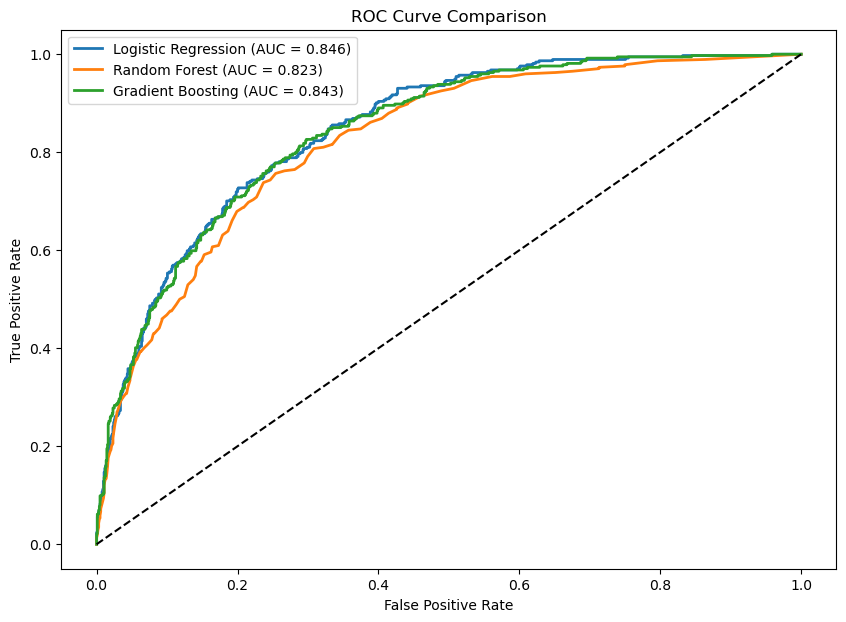

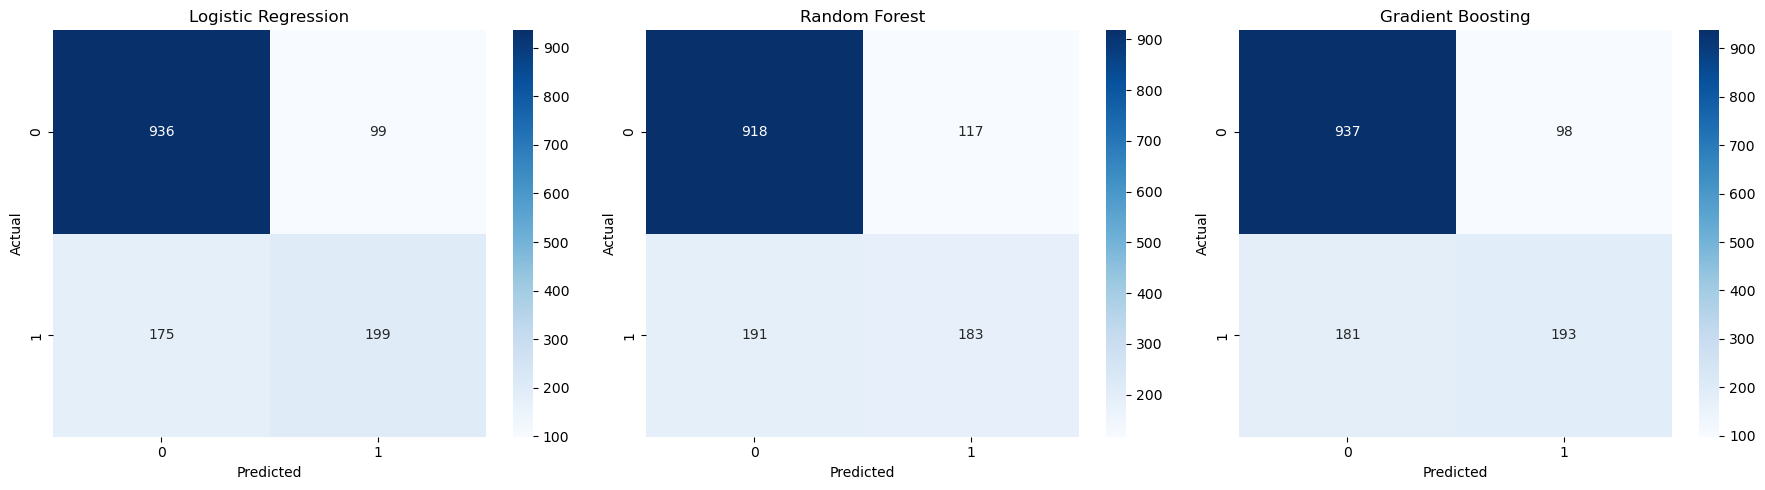


Best Parameters

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Model Performance

Accuracy : 0.797
Precision: 0.6803
Recall   : 0.4439
F1-Score : 0.5372
ROC-AUC  : 0.8414


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Different models for comparison
models = {
    "Logistic Regression": LogisticRegression(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = {}

# ROC Curve plot
plt.figure(figsize=(10,7))

for name, model in models.items():

    print(f"\n{name}")

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability scores for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))

    # ROC Curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Comparison table
results_df = pd.DataFrame(results).T

print("\nModel Comparison Table\n")

display(results_df)

# Diagonal baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig("model_comparison.png")

plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, (name, model) in zip(axes, models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax
    )

    ax.set_title(name)

    ax.set_xlabel("Predicted")

    ax.set_ylabel("Actual")

plt.tight_layout()

plt.show()

# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("\nBest Parameters\n")

print(grid_search.best_params_)

# Final evaluation after tuning
best_pred = best_model.predict(X_test)

best_prob = best_model.predict_proba(X_test)[:,1]

print("\nTuned Model Performance\n")

print("Accuracy :", round(accuracy_score(y_test, best_pred), 4))

print("Precision:", round(precision_score(y_test, best_pred), 4))

print("Recall   :", round(recall_score(y_test, best_pred), 4))

print("F1-Score :", round(f1_score(y_test, best_pred), 4))

print("ROC-AUC  :", round(roc_auc_score(y_test, best_prob), 4))

TASK 4 - Risk Segmentation

In [13]:
best_model = grid_search.best_estimator_

probabilities = best_model.predict_proba(X_test)[:,1]

risk_tiers = []

for p in probabilities:

    if p >= 0.70:
        risk_tiers.append("High Risk")

    elif p >= 0.40:
        risk_tiers.append("Medium Risk")

    else:
        risk_tiers.append("Low Risk")

risk_df = pd.DataFrame({
    'RiskTier': risk_tiers,
    'Probability': probabilities
})

print(risk_df['RiskTier'].value_counts())


RiskTier
Low Risk       986
Medium Risk    391
High Risk       32
Name: count, dtype: int64


Risk Tier Analysis

In [14]:
test_data = pd.DataFrame(X_test, columns=X.columns)

test_data['RiskTier'] = risk_tiers

summary = test_data.groupby('RiskTier').mean()

print(summary)

               gender  SeniorCitizen   Partner  Dependents    tenure  \
RiskTier                                                               
High Risk    0.115492       0.323136 -0.403798   -0.176473 -1.277445   
Low Risk     0.018885      -0.150999  0.151669    0.158538  0.324980   
Medium Risk -0.001840       0.309475 -0.388284   -0.335769 -0.781823   

             PhoneService  MultipleLines  InternetService  OnlineSecurity  \
RiskTier                                                                    
High Risk        0.327438      -0.266749         0.172250       -0.918838   
Low Risk         0.011928      -0.069868         0.058148        0.312658   
Medium Risk      0.059344       0.089687        -0.136287       -0.740360   

             OnlineBackup  ...  TechSupport  StreamingTV  StreamingMovies  \
RiskTier                   ...                                              
High Risk       -0.958905  ...    -0.925262    -0.477858        -0.556451   
Low Risk         0.154

TASK 5 - Visualizations

A. Feature Importance

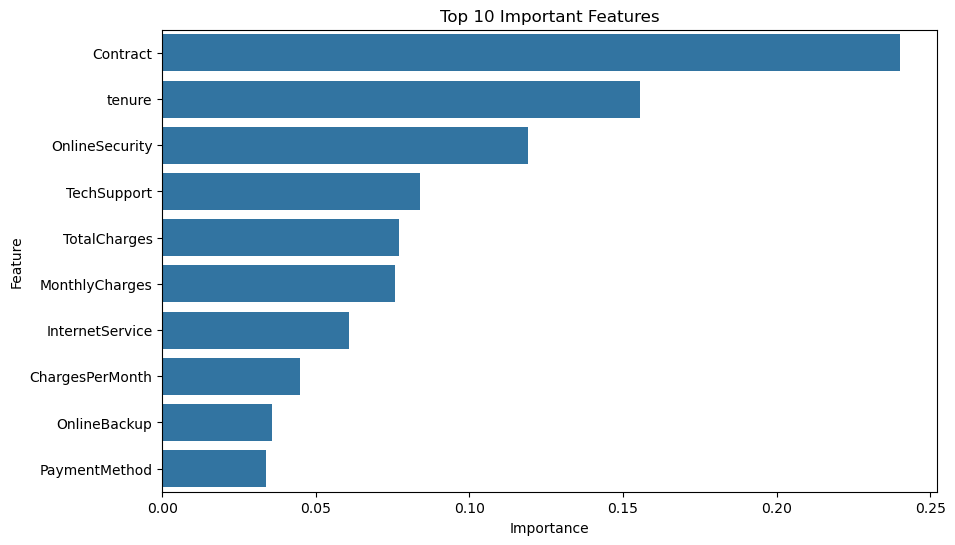

In [15]:
importances = best_model.feature_importances_

feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_imp.head(10)
)

plt.title("Top 10 Important Features")

plt.savefig("charts/feature_importance.png")

plt.show()

B. Churn by Contract Type

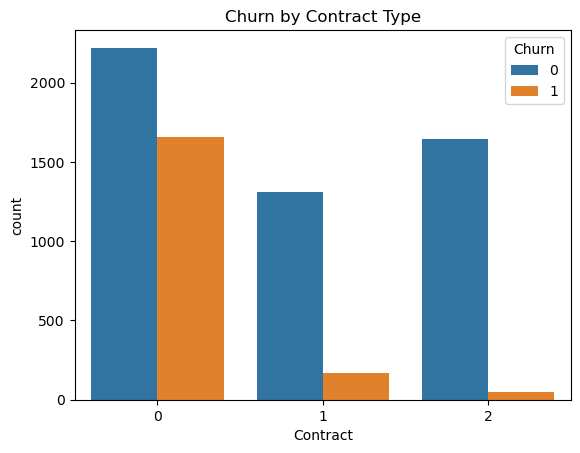

In [16]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Churn by Contract Type")

plt.savefig("charts/churn_contract.png")

plt.show()

C. Tenure Distribution

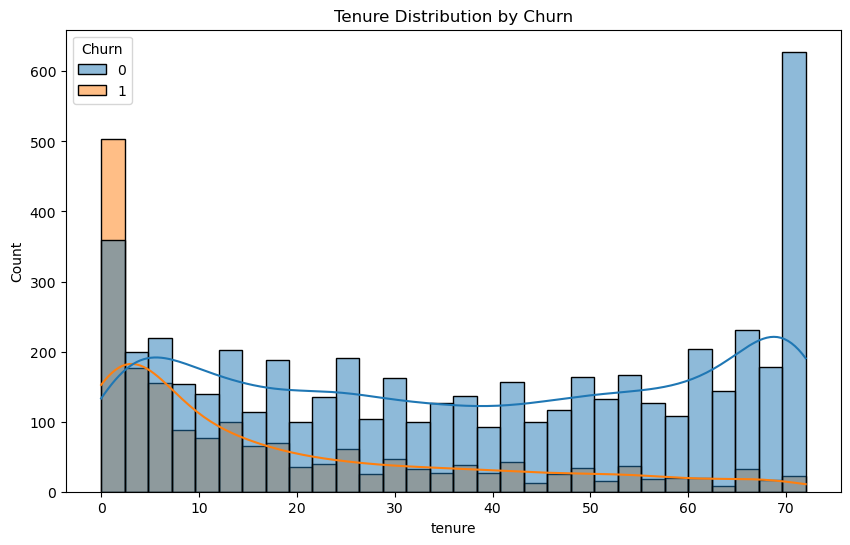

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True,
    bins=30
)

plt.title("Tenure Distribution by Churn")

plt.savefig("charts/tenure_distribution.png")

plt.show()

D. Risk Tier Pie Chart

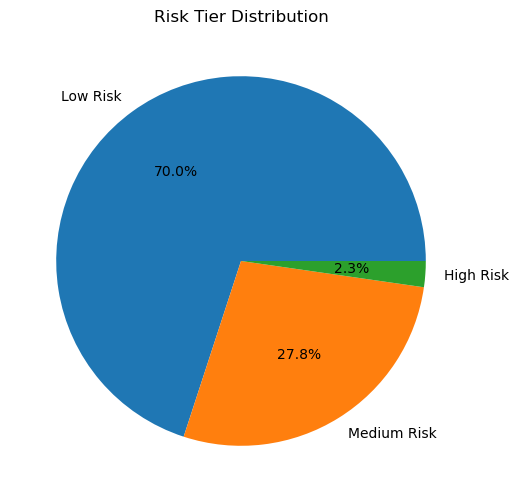

In [18]:
risk_counts = risk_df['RiskTier'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%'
)

plt.title("Risk Tier Distribution")

plt.savefig("charts/risk_tier_pie.png")

plt.show()

TASK 6 - Business Insights Section

1. Gradient Boosting performed best because it achieved the highest ROC-AUC score and balanced precision and recall effectively.

2. The top churn-driving factors were:
   - Contract Type
   - Tenure
   - Monthly Charges

3. High-risk customers usually had:
   - Month-to-month contracts
   - High monthly charges
   - Low tenure

4. Recommended business actions:
   - Offer discounts to high-risk customers before renewal.
   - Encourage long-term contracts with incentives.

5. Limitations:
   - Dataset lacks customer behavior history.
   - More features like customer support interactions could improve prediction accuracy.

In [20]:
!pip freeze > requirements.txt

In [21]:
import os
os.makedirs("charts", exist_ok=True)